In [23]:
import pandas as pd

df = pd.read_csv("../data/processed/paper_01.csv")
drop_cols = ["Text_Title", "Cutoff_Year", "Cutoff_Session"]
X = df.drop(columns=["App_Next"])
y = df[["App_Next"]]
X = df.drop(columns=drop_cols)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns
print(f"Num_cols: {num_cols}")
print(f"Cat_cols: {cat_cols}")

Num_cols: Index(['App_Total', 'Num_Stream_App', 'Yrs_Since_Last', 'Sessions_Since_Last',
       'Appd_Last_1', 'Appd_Last_2', 'Appd_Last_3', 'App_Next'],
      dtype='object')
Cat_cols: Index(['Paper_Stream'], dtype='object')


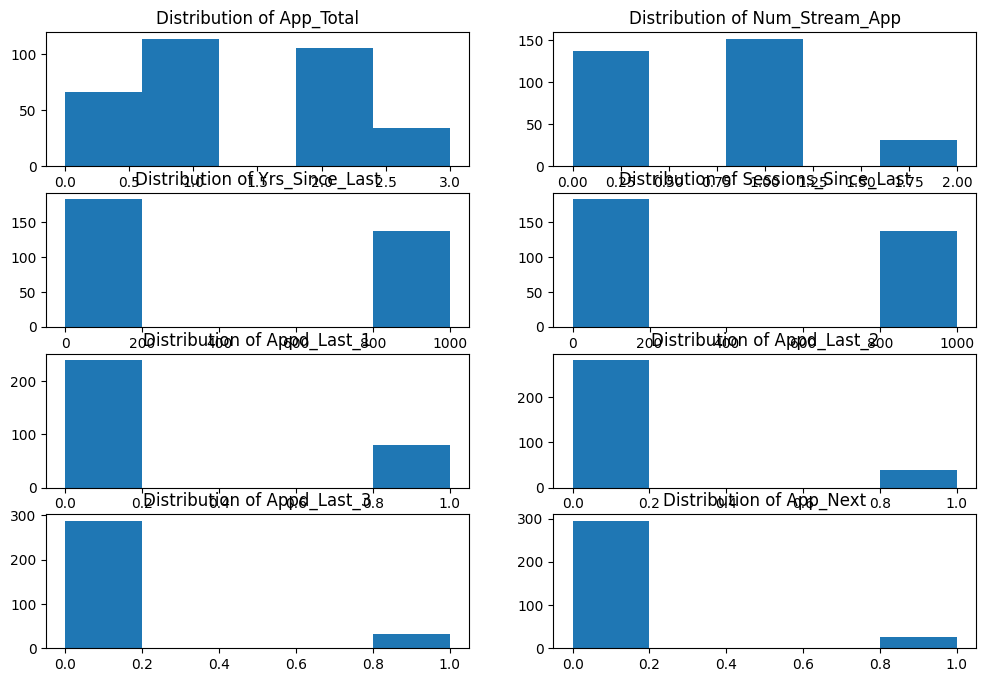

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(X[col].dropna(), bins=5)
    ax.set_title(f"Distribution of {col}")

plt.show()

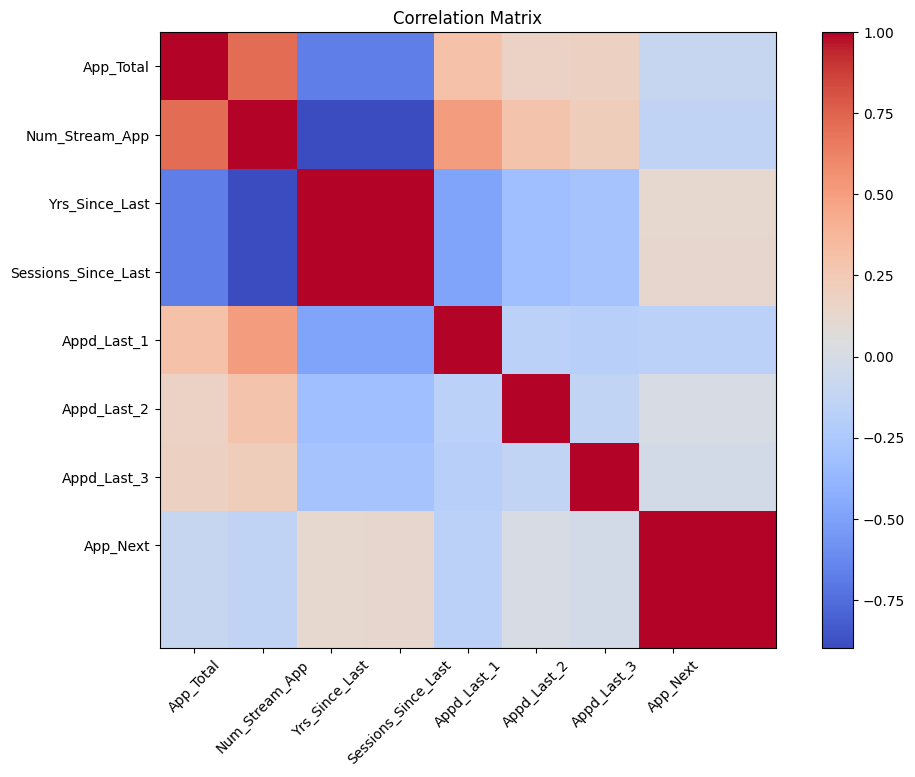

In [22]:
import numpy as np

df_corr = pd.concat([X[num_cols], y.astype(int)], axis=1)
corr = df_corr.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(np.arange(len(num_cols)), num_cols, rotation=45)
plt.yticks(np.arange(len(num_cols)), num_cols)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#The correlation matrix shows high multi-collinearity between Yrs_Since_Last & Sessions_Since_Last
#Sessions_Since_Last will be kept (since it is more relevant) and Yrs_Since_Last removed